#  Visualization
## Skin-Deep Insights: Aspect-Based Sentiment Analysis of Sephora Reviews

**Purpose:** Build polished, presentation-ready visualizations that tell the complete story of this analysis — from the problem to the findings to the recommendations.

**Design principles:**
- Every chart answers exactly one business question
- Charts are ordered to build a narrative, not just display data
- Colors are consistent and intentional throughout
- Every chart is saved as a high-resolution PNG for use in presentations

**Color system used throughout:**
```
RED     #F44336  → complaints, negatives, problems
GREEN   #4CAF50  → positives, strengths
YELLOW  #FFC107  → neutral, moderate
MAGMA           → ordered intensity (brand volume, counts)
STEEL BLUE      → neutral informational bars
```

**12 charts — organized as a story:**
```
ACT 1 — THE PROBLEM (Charts 1-3)
  Chart 01: The Rating Skew — why star ratings mislead
  Chart 02: Hidden Dissatisfaction — the gap between ratings and text
  Chart 03: Sentiment by Rating — VADER validation visual

ACT 2 — THE FINDINGS (Charts 4-8)
  Chart 04: Aspect Sentiment Breakdown — the core result
  Chart 05: Hidden Complaint Rate — what hides inside 4★+ reviews
  Chart 06: Hidden Complaint Volume — rate vs count distinction
  Chart 07: Skin Type Heatmap — who complains most about what
  Chart 08: Price Tier Breakdown — does price predict quality?

ACT 3 — THE EVIDENCE (Charts 9-10)
  Chart 09: TF-IDF Complaint Words — data-driven aspect discovery
  Chart 10: Complaint Trend 2018-2023 — are things getting better?

ACT 4 — THE RECOMMENDATIONS (Charts 11-12)
  Chart 11: Priority Matrix — aspect rate vs volume
  Chart 12: Recommendations Dashboard — the complete action plan
```
---

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
import warnings
warnings.filterwarnings('ignore')

# ── Global style ──────────────────────────────────────────────
plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'figure.dpi':        120
})

# ── Color palette ─────────────────────────────────────────────
C_NEG    = '#F44336'   # red — complaints
C_POS    = '#4CAF50'   # green — strengths
C_NEU    = '#FFC107'   # yellow — neutral
C_BLUE   = '#1976D2'   # blue — informational
C_PINK   = '#E91E63'   # pink — skin_reaction
C_ORANGE = '#FF5722'   # orange — texture

ASPECT_COLORS = {
    'packaging':     C_NEG,
    'skin_reaction': C_PINK,
    'price':         '#FF9800',
    'texture':       C_ORANGE,
    'hydration':     C_POS,
    'scent':         C_BLUE
}

# ── Load data ─────────────────────────────────────────────────
df = pd.read_csv('../sephora/clean_reviews.csv', parse_dates=['review_date'])
df['price_tier'] = pd.cut(
    df['price_usd'], bins=[0, 25, 50, 100, 9999],
    labels=['budget(<$25)', 'mid($25-50)', 'premium($50-100)', 'luxury($100+)']
)
df_sample = df.sample(n=300000, random_state=42).copy()

# ── VADER ─────────────────────────────────────────────────────
analyzer = SentimentIntensityAnalyzer()
df_sample['vader_score'] = df_sample['review_text'].apply(
    lambda x: analyzer.polarity_scores(str(x))['compound']
)
df_sample['sentiment_label'] = df_sample['vader_score'].apply(
    lambda x: 'positive' if x >= 0.05 else ('negative' if x <= -0.05 else 'neutral')
)

# ── Aspects ───────────────────────────────────────────────────
aspect_keywords = {
    'packaging':     ['pump','bottle','packaging','break','broke','leaked','cap','tube'],
    'skin_reaction': ['breakout','acne','irritation','rash','sensitive',
                      'reaction','redness','burning','purging','clog'],
    'scent':         ['smell','scent','fragrance','odor','perfume','fragrant','stinks'],
    'texture':       ['texture','consistency','thick','thin','creamy',
                      'lightweight','heavy','greasy','sticky','watery'],
    'hydration':     ['hydrating','moisturizing','dry','moisture',
                      'hydration','dewy','plump','tight'],
    'price':         ['expensive','cheap','worth','overpriced',
                      'value','affordable','price','cost']
}

def extract_aspects(text):
    found = [a for a, kws in aspect_keywords.items()
             if any(k in str(text).lower() for k in kws)]
    return found if found else ['none']

df_sample['aspects'] = df_sample['clean_text'].apply(extract_aspects)
df_exp = df_sample.explode('aspects').copy()
df_exp = df_exp[df_exp['aspects'] != 'none']
df_4p  = df_exp[df_exp['rating'] >= 4].copy()

# ── Master table ──────────────────────────────────────────────
tot   = df_exp.groupby('aspects').size().rename('total')
neg_r = (df_exp[df_exp['sentiment_label']=='negative']
         .groupby('aspects').size() / tot * 100).round(1).rename('neg_pct')
tot4  = df_4p.groupby('aspects').size().rename('total_4p')
neg4c = df_4p[df_4p['sentiment_label']=='negative'].groupby('aspects').size()
neg4r = (neg4c / tot4 * 100).round(1).rename('neg_pct_4p')
master = pd.concat([tot, neg_r, tot4, neg4r,
                    neg4c.rename('neg_count_4p')], axis=1)

print('Setup complete.')
print(master.sort_values('neg_pct_4p', ascending=False))

Setup complete.
                total  neg_pct  total_4p  neg_pct_4p  neg_count_4p
aspects                                                           
skin_reaction   74723     10.1     60700         5.4          3292
packaging       61315     11.5     45906         4.8          2201
price           46752      7.8     35700         3.5          1249
texture        125969      7.8     98872         3.5          3488
hydration      101187      6.2     84729         3.4          2881
scent           74495      5.7     60218         2.3          1394


---
## ACT 1 — THE PROBLEM

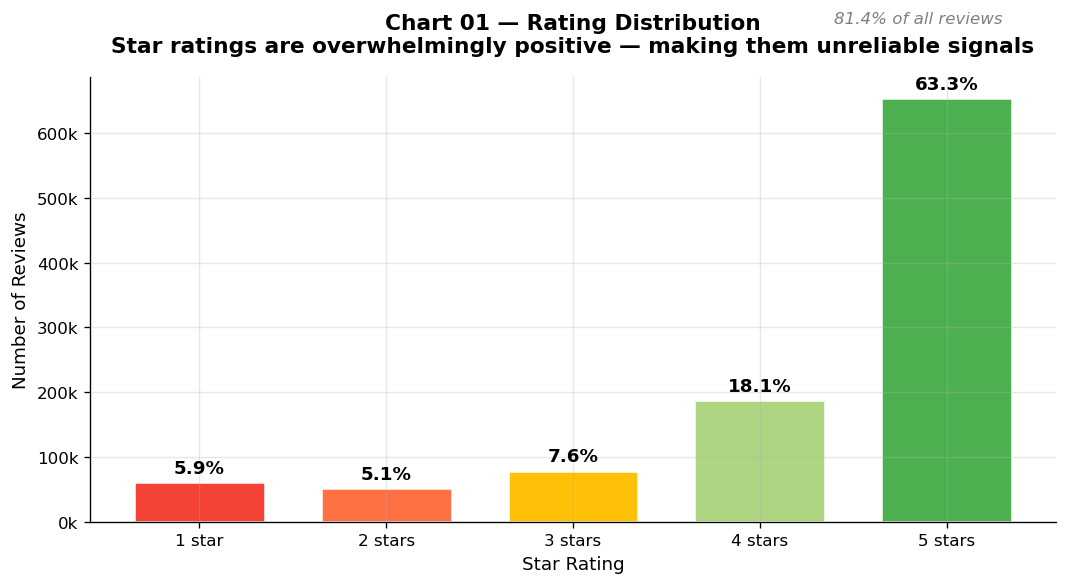

Chart 01 saved.


In [2]:
# ── Chart 01: Rating Distribution ──────────────────────────────
rating_counts = df['rating'].value_counts().sort_index()
rating_pct    = df['rating'].value_counts(normalize=True).sort_index() * 100

fig, ax = plt.subplots(figsize=(9, 5))

bar_colors = [C_NEG, '#FF7043', C_NEU, '#AED581', C_POS]
bars = ax.bar(rating_counts.index, rating_counts.values,
              color=bar_colors, edgecolor='white', linewidth=1.5, width=0.7)

for bar, pct in zip(bars, rating_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 8000,
            f'{pct:.1f}%', ha='center', va='bottom',
            fontweight='bold', fontsize=11)

# Highlight the 4+5 star zone
ax.annotate('', xy=(4.35, 750000), xytext=(5.35, 750000),
            arrowprops=dict(arrowstyle='<->', color='gray', lw=2))
ax.text(4.85, 770000, '81.4% of all reviews',
        ha='center', fontsize=10, color='gray', style='italic')

ax.set_title('Chart 01 — Rating Distribution\n'
             'Star ratings are overwhelmingly positive — making them unreliable signals',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Star Rating', fontsize=11)
ax.set_ylabel('Number of Reviews', fontsize=11)
ax.set_xticks([1,2,3,4,5])
ax.set_xticklabels(['1 star','2 stars','3 stars','4 stars','5 stars'])
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

plt.tight_layout()
plt.savefig('chart01_rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 01 saved.')

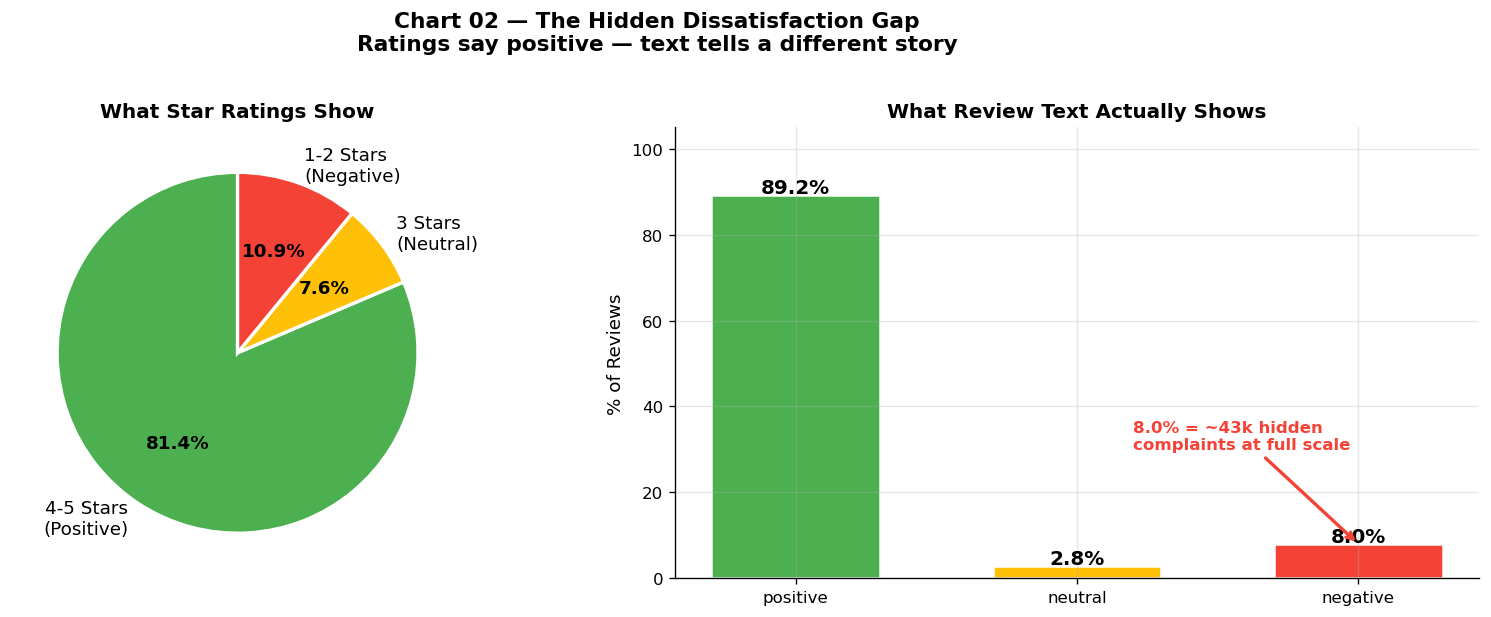

Chart 02 saved.


In [3]:
# ── Chart 02: The Hidden Dissatisfaction Gap ────────────────────
sent_dist = df_sample['sentiment_label'].value_counts(normalize=True) * 100
sent_dist = sent_dist.reindex(['positive','neutral','negative'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: what ratings show
four_five = (rating_pct[4] + rating_pct[5])
one_two   = (rating_pct[1] + rating_pct[2])
three     = rating_pct[3]

wedges, texts, autotexts = axes[0].pie(
    [four_five, three, one_two],
    labels=['4-5 Stars\n(Positive)', '3 Stars\n(Neutral)', '1-2 Stars\n(Negative)'],
    colors=[C_POS, C_NEU, C_NEG],
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 11}
)
for at in autotexts:
    at.set_fontweight('bold')
axes[0].set_title('What Star Ratings Show',
                  fontsize=12, fontweight='bold')

# Right: what text actually shows
bar_colors_sent = [C_POS, C_NEU, C_NEG]
bars2 = axes[1].bar(sent_dist.index, sent_dist.values,
                    color=bar_colors_sent, edgecolor='white',
                    linewidth=1.5, width=0.6)
for bar, val in zip(bars2, sent_dist.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center',
                 fontweight='bold', fontsize=12)

# Annotate the gap
axes[1].annotate(
    f'8.0% = ~{int(len(df)*0.0419/1000)}k hidden\ncomplaints at full scale',
    xy=(2, sent_dist['negative']), xytext=(1.2, 30),
    arrowprops=dict(arrowstyle='->', color=C_NEG, lw=2),
    fontsize=10, color=C_NEG, fontweight='bold'
)

axes[1].set_title('What Review Text Actually Shows',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('% of Reviews', fontsize=11)
axes[1].set_ylim(0, 105)

fig.suptitle('Chart 02 — The Hidden Dissatisfaction Gap\n'
             'Ratings say positive — text tells a different story',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart02_hidden_dissatisfaction_gap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 02 saved.')

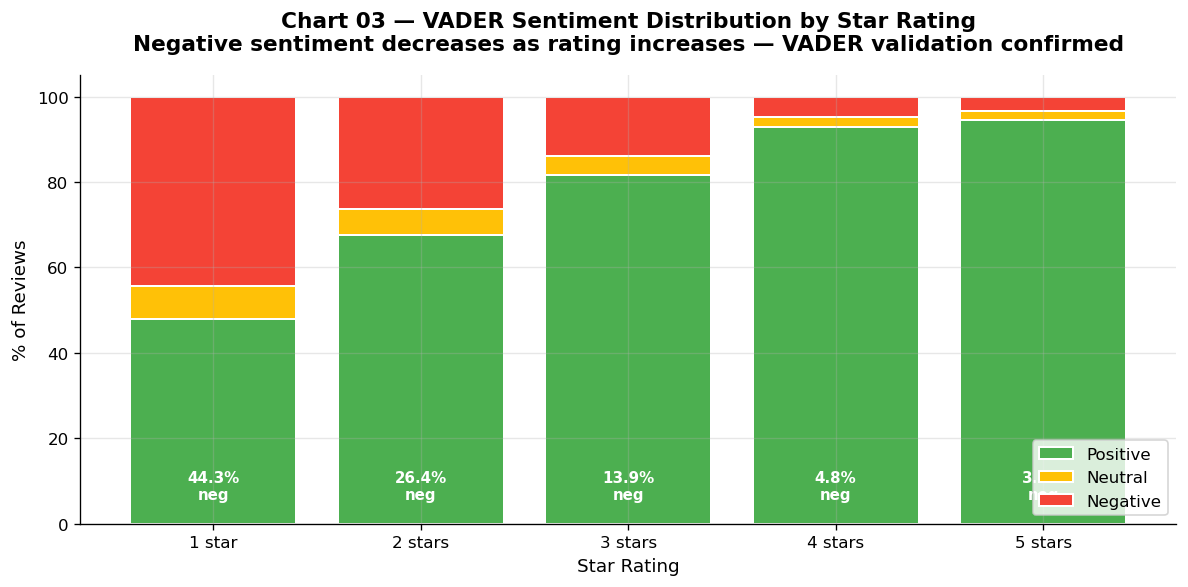

Chart 03 saved.


In [4]:
# ── Chart 03: VADER Sentiment by Rating ─────────────────────────
crosstab = pd.crosstab(
    df_sample['rating'],
    df_sample['sentiment_label'],
    normalize='index'
) * 100
crosstab = crosstab.reindex(columns=['positive','neutral','negative'])

fig, ax = plt.subplots(figsize=(10, 5))

col_colors = [C_POS, C_NEU, C_NEG]
bottom = np.zeros(len(crosstab))
for col, color in zip(['positive','neutral','negative'], col_colors):
    if col in crosstab.columns:
        ax.bar(crosstab.index, crosstab[col], bottom=bottom,
               label=col.capitalize(), color=color,
               edgecolor='white', linewidth=1.2)
        bottom += crosstab[col].values

# Add neg % labels
for rating, neg_val in crosstab['negative'].items():
    ax.text(rating, 5, f'{neg_val:.1f}%\nneg',
            ha='center', va='bottom', fontsize=9,
            fontweight='bold', color='white')

ax.set_title('Chart 03 — VADER Sentiment Distribution by Star Rating\n'
             'Negative sentiment decreases as rating increases — VADER validation confirmed',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Star Rating', fontsize=11)
ax.set_ylabel('% of Reviews', fontsize=11)
ax.set_xticks([1,2,3,4,5])
ax.set_xticklabels(['1 star','2 stars','3 stars','4 stars','5 stars'])
ax.legend(loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig('chart03_vader_by_rating.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 03 saved.')

---
## ACT 2 — THE FINDINGS

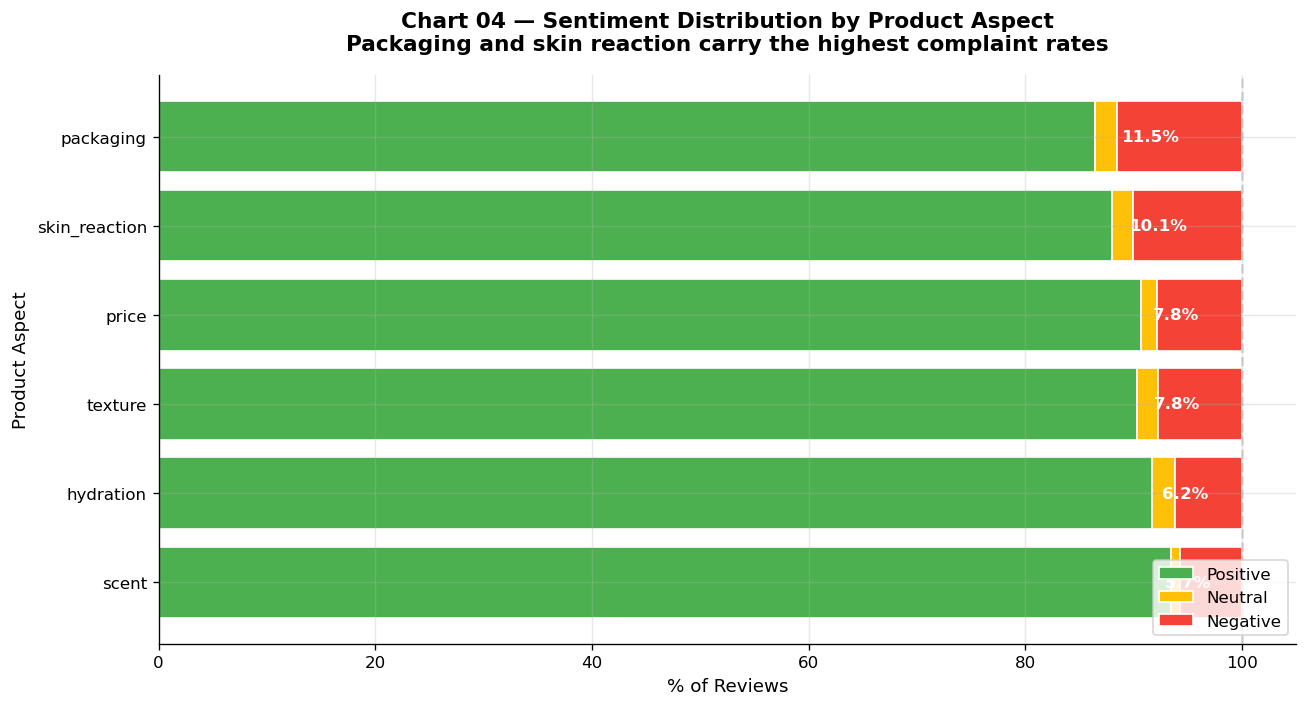

Chart 04 saved.


In [5]:
# ── Chart 04: Aspect Sentiment Breakdown ────────────────────────
asp_sent = pd.crosstab(
    df_exp['aspects'], df_exp['sentiment_label'], normalize='index'
) * 100
asp_sent = asp_sent.reindex(columns=['positive','neutral','negative'])
asp_sent = asp_sent.sort_values('negative', ascending=True)

fig, ax = plt.subplots(figsize=(11, 6))

col_colors = [C_POS, C_NEU, C_NEG]
left = np.zeros(len(asp_sent))
for col, color in zip(['positive','neutral','negative'], col_colors):
    if col in asp_sent.columns:
        bars = ax.barh(asp_sent.index, asp_sent[col], left=left,
                       label=col.capitalize(), color=color,
                       edgecolor='white', linewidth=1)
        left += asp_sent[col].values

# Add negative % labels
for i, (aspect, row) in enumerate(asp_sent.iterrows()):
    ax.text(100 - row.get('negative', 0) / 2,
            i, f"{row.get('negative', 0):.1f}%",
            ha='right', va='center',
            fontweight='bold', fontsize=10, color='white')

ax.set_title('Chart 04 — Sentiment Distribution by Product Aspect\n'
             'Packaging and skin reaction carry the highest complaint rates',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('% of Reviews', fontsize=11)
ax.set_ylabel('Product Aspect', fontsize=11)
ax.set_xlim(0, 105)
ax.legend(loc='lower right', fontsize=10)
ax.axvline(x=100, color='gray', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('chart04_aspect_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 04 saved.')

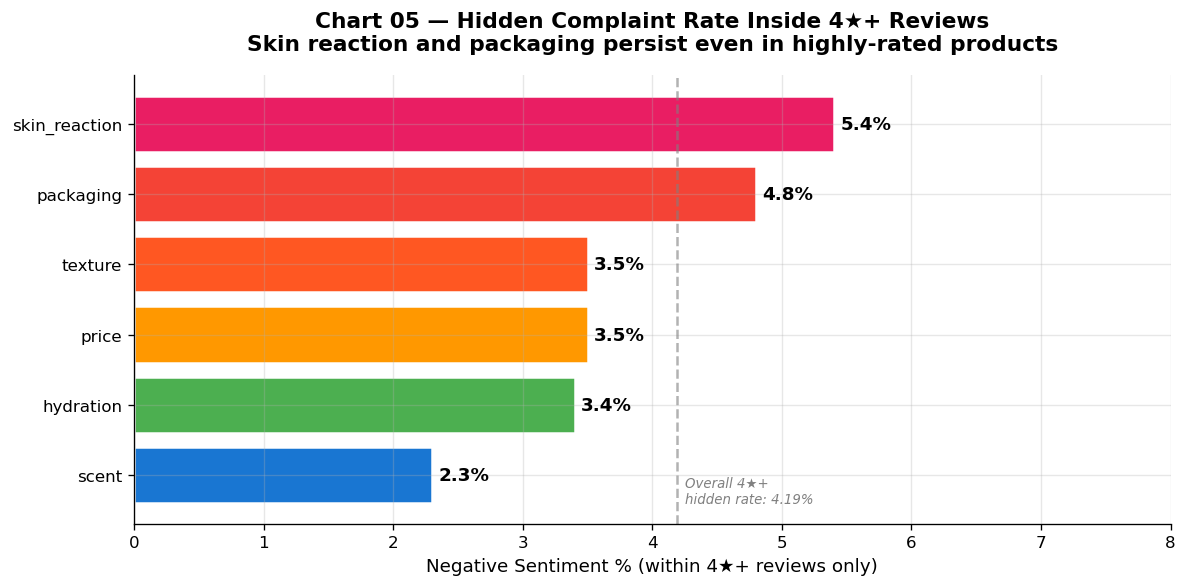

Chart 05 saved.


In [6]:
# ── Chart 05: Hidden Complaint Rate in 4★+ ──────────────────────
hidden_sorted = master.sort_values('neg_pct_4p', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))

bar_colors_h = [ASPECT_COLORS.get(a, C_BLUE)
                for a in hidden_sorted.index]
bars = ax.barh(hidden_sorted.index, hidden_sorted['neg_pct_4p'],
               color=bar_colors_h, edgecolor='white', linewidth=1.5)

for bar, val in zip(bars, hidden_sorted['neg_pct_4p']):
    ax.text(val + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontweight='bold', fontsize=11)

ax.set_title('Chart 05 — Hidden Complaint Rate Inside 4★+ Reviews\n'
             'Skin reaction and packaging persist even in highly-rated products',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Negative Sentiment % (within 4★+ reviews only)', fontsize=11)
ax.set_xlim(0, 8)

ax.axvline(x=4.19, color='gray', linestyle='--', alpha=0.6)
ax.text(4.25, -0.4, 'Overall 4★+\nhidden rate: 4.19%',
        fontsize=8, color='gray', style='italic')

plt.tight_layout()
plt.savefig('chart05_hidden_complaint_rate.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 05 saved.')

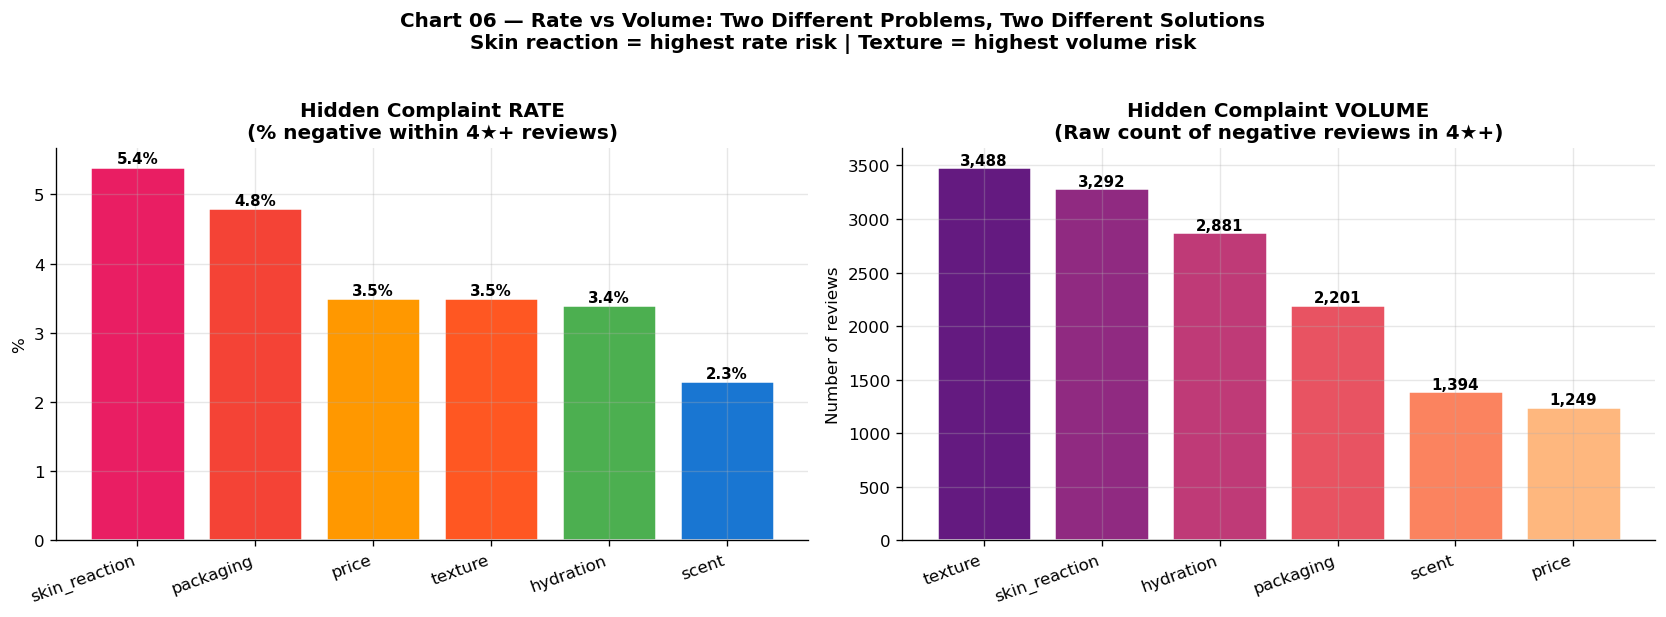

Chart 06 saved.


In [7]:
# ── Chart 06: Rate vs Volume — the key distinction ──────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: hidden rate (sorted by rate)
rate_sorted = master.sort_values('neg_pct_4p', ascending=False)
colors_rate = [ASPECT_COLORS.get(a, C_BLUE) for a in rate_sorted.index]
bars1 = axes[0].bar(range(len(rate_sorted)), rate_sorted['neg_pct_4p'],
                    color=colors_rate, edgecolor='white', linewidth=1.5)
axes[0].set_xticks(range(len(rate_sorted)))
axes[0].set_xticklabels(rate_sorted.index, rotation=20, ha='right')
axes[0].set_title('Hidden Complaint RATE\n(% negative within 4★+ reviews)',
                  fontweight='bold')
axes[0].set_ylabel('%')
for bar, val in zip(bars1, rate_sorted['neg_pct_4p']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.05,
                 f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

# Right: hidden count (sorted by count)
count_sorted = master.sort_values('neg_count_4p', ascending=False)
colors_count = [ASPECT_COLORS.get(a, C_BLUE) for a in count_sorted.index]
cmap_magma = plt.get_cmap('magma')
colors_m = cmap_magma(np.linspace(0.3, 0.85, len(count_sorted)))
bars2 = axes[1].bar(range(len(count_sorted)), count_sorted['neg_count_4p'],
                    color=colors_m, edgecolor='white', linewidth=1.5)
axes[1].set_xticks(range(len(count_sorted)))
axes[1].set_xticklabels(count_sorted.index, rotation=20, ha='right')
axes[1].set_title('Hidden Complaint VOLUME\n(Raw count of negative reviews in 4★+)',
                  fontweight='bold')
axes[1].set_ylabel('Number of reviews')
for bar, val in zip(bars2, count_sorted['neg_count_4p']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 20,
                 f'{val:,.0f}', ha='center', fontsize=9, fontweight='bold')

fig.suptitle('Chart 06 — Rate vs Volume: Two Different Problems, Two Different Solutions\n'
             'Skin reaction = highest rate risk | Texture = highest volume risk',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart06_rate_vs_volume.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 06 saved.')

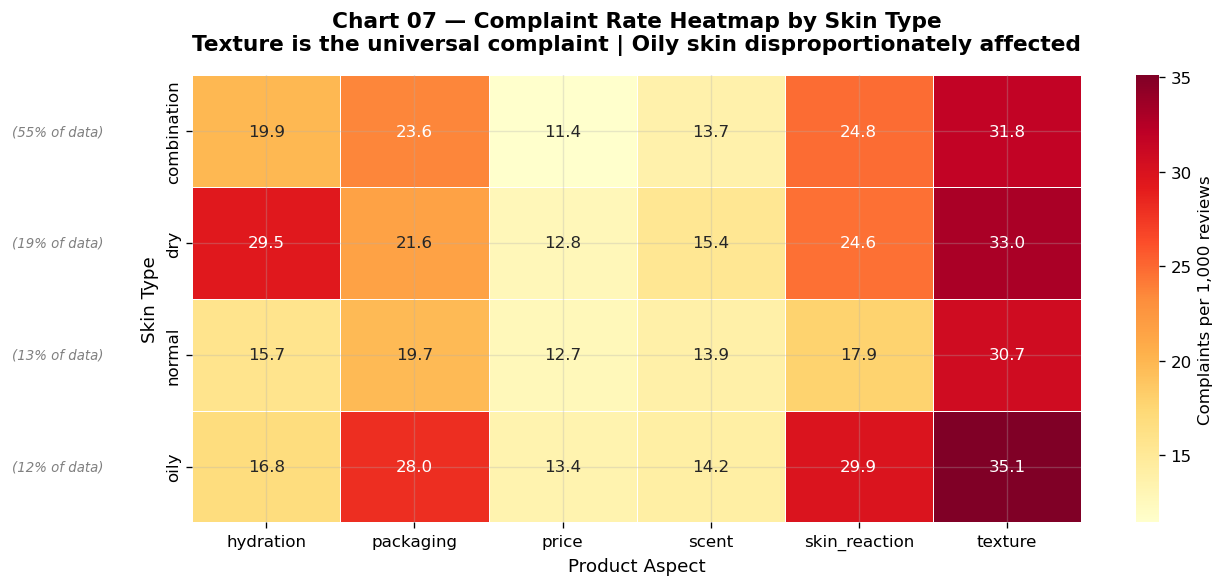

Chart 07 saved.


In [8]:
# ── Chart 07: Skin Type Complaint Heatmap ───────────────────────
skin_totals = df_sample['skin_type'].value_counts()

skin_neg = df_exp[df_exp['sentiment_label']=='negative']\
    .groupby(['skin_type','aspects']).size().unstack(fill_value=0)

# Rate per 1000 reviews
skin_rate = skin_neg.div(skin_totals, axis=0) * 1000
skin_rate = skin_rate.loc[
    skin_rate.index.isin(['combination','dry','normal','oily'])
][['hydration','packaging','price','scent','skin_reaction','texture']]

fig, ax = plt.subplots(figsize=(11, 5))

sns.heatmap(
    skin_rate, annot=True, fmt='.1f',
    cmap='YlOrRd', ax=ax,
    cbar_kws={'label': 'Complaints per 1,000 reviews'},
    linewidths=0.5, linecolor='white'
)

ax.set_title('Chart 07 — Complaint Rate Heatmap by Skin Type\n'
             'Texture is the universal complaint | Oily skin disproportionately affected',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Product Aspect', fontsize=11)
ax.set_ylabel('Skin Type', fontsize=11)

# Annotate dataset representation
skin_rep = skin_totals / skin_totals.sum() * 100
for i, skin in enumerate(skin_rate.index):
    pct = skin_rep.get(skin, 0)
    ax.text(-0.6, i + 0.5, f'({pct:.0f}% of data)',
            va='center', ha='right', fontsize=8,
            color='gray', style='italic')

plt.tight_layout()
plt.savefig('chart07_skin_type_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 07 saved.')

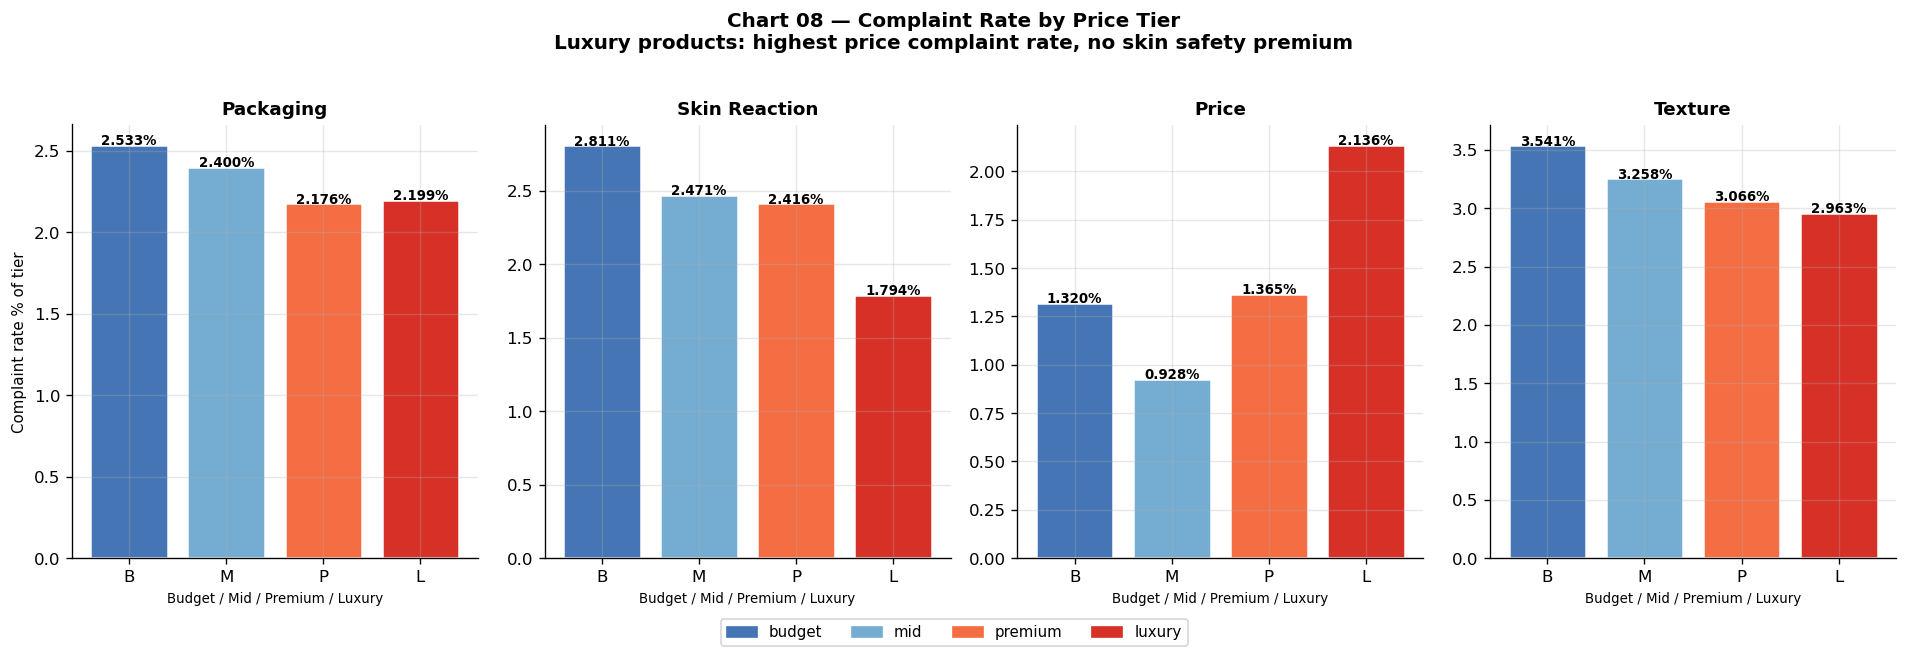

Chart 08 saved.


In [9]:
# ── Chart 08: Price Tier Analysis ───────────────────────────────
tier_totals = df_sample['price_tier'].value_counts()

if 'price_tier' not in df_exp.columns:
    df_exp['price_tier'] = pd.cut(
        df_exp['price_usd'], bins=[0, 25, 50, 100, 9999],
        labels=['budget(<$25)','mid($25-50)','premium($50-100)','luxury($100+)']
    )

tiers = ['budget(<$25)','mid($25-50)','premium($50-100)','luxury($100+)']
tier_colors = ['#4575b4','#74add1','#f46d43','#d73027']

# Complaint rates per tier
aspects_show = ['packaging','skin_reaction','price','texture']
rates = {}
for asp in aspects_show:
    neg = df_exp[(df_exp['aspects']==asp) &
                 (df_exp['sentiment_label']=='negative')]\
        .groupby('price_tier', observed=False).size()
    rates[asp] = (neg / tier_totals * 100).fillna(0)

fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for idx, (asp, ax) in enumerate(zip(aspects_show, axes)):
    vals = [rates[asp].get(t, 0) for t in tiers]
    bars = ax.bar(range(4), vals, color=tier_colors, edgecolor='white', linewidth=1.5)
    ax.set_title(asp.replace('_',' ').title(), fontweight='bold', fontsize=11)
    ax.set_xticks(range(4))
    ax.set_xticklabels(['B', 'M', 'P', 'L'], fontsize=10)
    ax.set_xlabel('Budget / Mid / Premium / Luxury', fontsize=8)
    if idx == 0:
        ax.set_ylabel('Complaint rate % of tier', fontsize=9)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.001,
                f'{val:.3f}%', ha='center', fontsize=8, fontweight='bold')

fig.suptitle('Chart 08 — Complaint Rate by Price Tier\n'
             'Luxury products: highest price complaint rate, no skin safety premium',
             fontsize=12, fontweight='bold', y=1.02)

legend_patches = [mpatches.Patch(color=c, label=t.split('(')[0])
                  for c, t in zip(tier_colors, tiers)]
fig.legend(handles=legend_patches, loc='lower center',
           ncol=4, bbox_to_anchor=(0.5, -0.05), fontsize=9)

plt.tight_layout()
plt.savefig('chart08_price_tier.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 08 saved.')

---
## ACT 3 — THE EVIDENCE

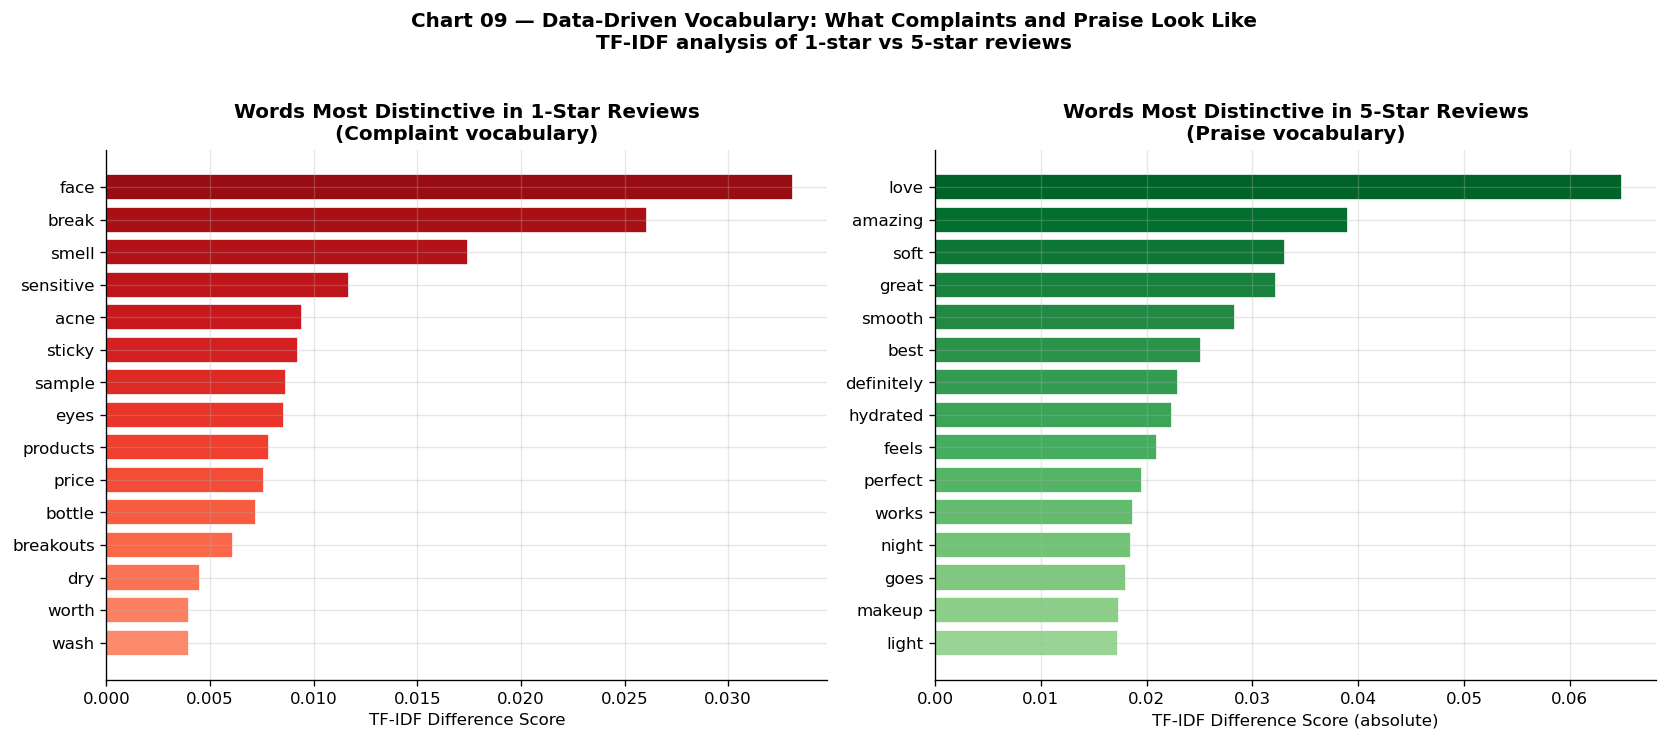

Chart 09 saved.


In [10]:
# ── Chart 09: TF-IDF Complaint Words ────────────────────────────
df_1s = df[df['rating']==1]['clean_text'].dropna()
df_5s = df[df['rating']==5]['clean_text'].dropna()

custom_stops = [
    'ive','im','dont','cant','didnt','doesnt','wasnt','wouldnt',
    'isnt','thats','its','really','just','little','use','using',
    'used','product','got','try','tried','did','like','felt',
    'feel','better','good','sure','think','time','pretty','new',
    'days','weeks','work','bought','buy','left','started',
    'actually','does','away','months','difference'
]
all_stops = list(ENGLISH_STOP_WORDS) + custom_stops

tfidf = TfidfVectorizer(stop_words=all_stops, max_features=100)
tfidf.fit(df['clean_text'].dropna())
X1 = tfidf.transform(df_1s)
X5 = tfidf.transform(df_5s)
words = tfidf.get_feature_names_out()
s1 = np.asarray(X1.mean(axis=0)).flatten()
s5 = np.asarray(X5.mean(axis=0)).flatten()
diff_df = pd.DataFrame({'word':words,'s1':s1,'s5':s5,'diff':s1-s5})\
    .sort_values('diff', ascending=False)

top_comp = diff_df.head(15)
top_prai = diff_df.tail(15).sort_values('diff')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: complaint words
cmap_r = plt.get_cmap('Reds')
colors_c = cmap_r(np.linspace(0.4, 0.9, len(top_comp)))
axes[0].barh(top_comp['word'], top_comp['diff'],
             color=colors_c[::-1], edgecolor='white')
axes[0].set_title('Words Most Distinctive in 1-Star Reviews\n(Complaint vocabulary)',
                  fontweight='bold')
axes[0].set_xlabel('TF-IDF Difference Score')
axes[0].invert_yaxis()

# Right: praise words
cmap_g = plt.get_cmap('Greens')
colors_p = cmap_g(np.linspace(0.4, 0.9, len(top_prai)))
axes[1].barh(top_prai['word'], top_prai['diff'].abs(),
             color=colors_p[::-1], edgecolor='white')
axes[1].set_title('Words Most Distinctive in 5-Star Reviews\n(Praise vocabulary)',
                  fontweight='bold')
axes[1].set_xlabel('TF-IDF Difference Score (absolute)')
axes[1].invert_yaxis()

fig.suptitle('Chart 09 — Data-Driven Vocabulary: What Complaints and Praise Look Like\n'
             'TF-IDF analysis of 1-star vs 5-star reviews',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart09_tfidf_vocab.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 09 saved.')

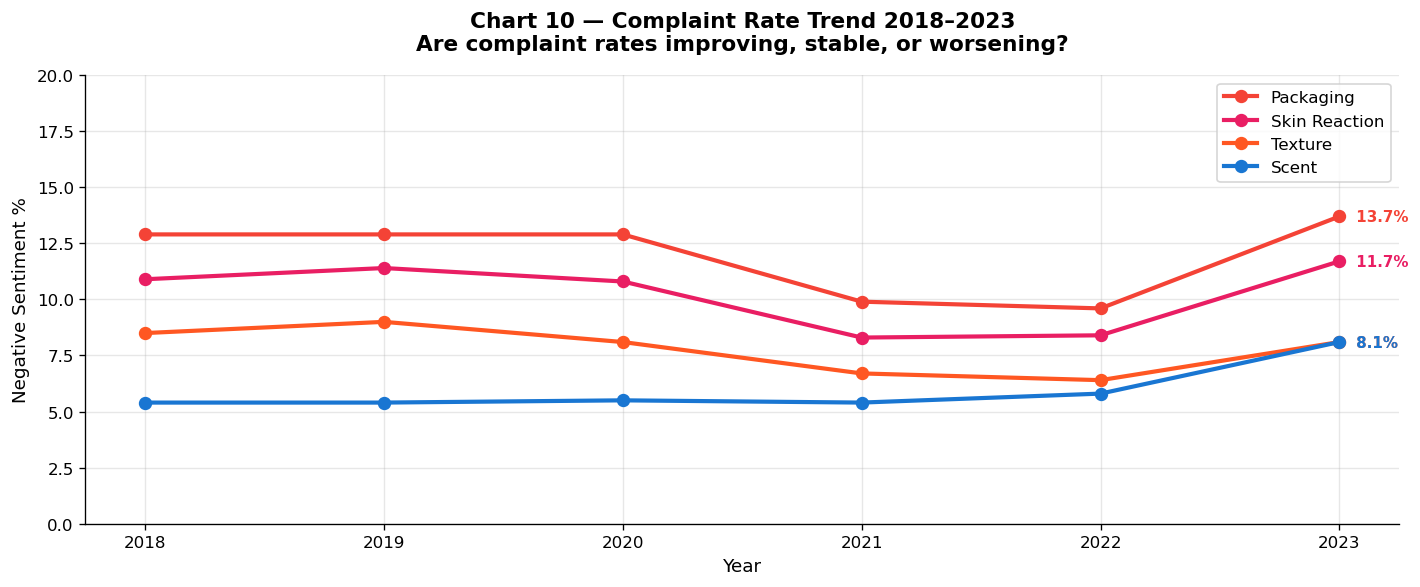

Chart 10 saved.


In [11]:
# ── Chart 10: Complaint Trend 2018-2023 ─────────────────────────
df_exp['year'] = df_exp['review_date'].dt.year

trend_data = []
for year in range(2018, 2024):
    yd = df_exp[df_exp['year'] == year]
    for asp in ['packaging', 'skin_reaction', 'texture', 'scent']:
        tot_a = len(yd[yd['aspects'] == asp])
        neg_a = len(yd[(yd['aspects']==asp) &
                       (yd['sentiment_label']=='negative')])
        if tot_a > 100:
            trend_data.append({'year':year, 'aspect':asp,
                                'neg_rate': round(neg_a/tot_a*100, 1),
                                'mentions': tot_a})

trend_df = pd.DataFrame(trend_data)

fig, ax = plt.subplots(figsize=(12, 5))

trend_colors = {
    'packaging':     C_NEG,
    'skin_reaction': C_PINK,
    'texture':       C_ORANGE,
    'scent':         C_BLUE
}

for asp in ['packaging', 'skin_reaction', 'texture', 'scent']:
    asp_d = trend_df[trend_df['aspect']==asp].sort_values('year')
    if len(asp_d) > 1:
        ax.plot(asp_d['year'], asp_d['neg_rate'],
                marker='o', linewidth=2.5, markersize=7,
                color=trend_colors[asp],
                label=asp.replace('_',' ').title())
        # Label last point
        last = asp_d.iloc[-1]
        ax.text(last['year'] + 0.05, last['neg_rate'],
                f" {last['neg_rate']}%", va='center',
                fontsize=9, color=trend_colors[asp], fontweight='bold')

ax.set_title('Chart 10 — Complaint Rate Trend 2018–2023\n'
             'Are complaint rates improving, stable, or worsening?',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Negative Sentiment %', fontsize=11)
ax.set_xticks(range(2018, 2024))
ax.legend(fontsize=10)
ax.set_ylim(0, 20)

plt.tight_layout()
plt.savefig('chart10_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 10 saved.')

---
## ACT 4 — THE RECOMMENDATIONS

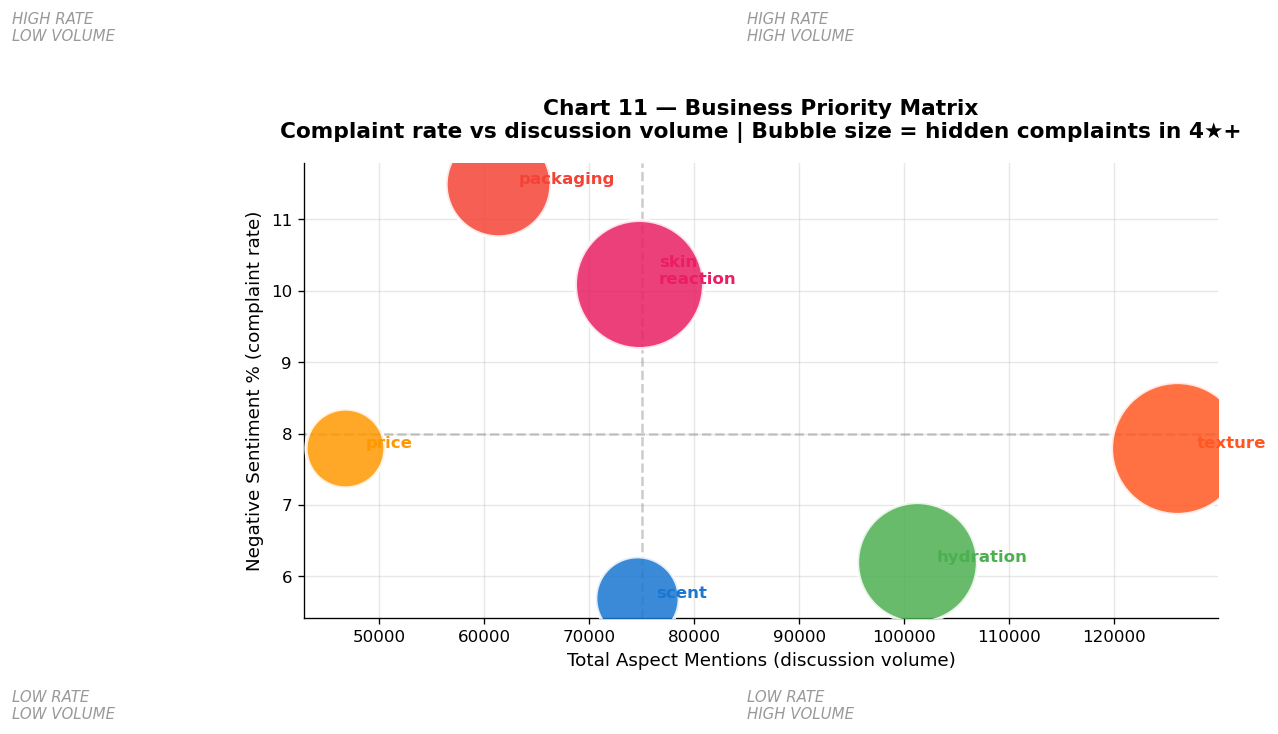

Chart 11 saved.


In [12]:
# ── Chart 11: Priority Matrix ────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 7))

for asp in master.index:
    x = master.loc[asp, 'total']
    y = master.loc[asp, 'neg_pct']
    size = master.loc[asp, 'neg_count_4p'] * 1.8
    color = ASPECT_COLORS.get(asp, C_BLUE)

    ax.scatter(x, y, s=size, c=color, alpha=0.85,
               edgecolors='white', linewidth=2, zorder=3)
    ax.annotate(
        asp.replace('_', '\n'),
        (x, y), textcoords='offset points',
        xytext=(12, 0), fontsize=10, fontweight='bold',
        color=color
    )

# Reference lines
ax.axhline(y=8, color='gray', linestyle='--', alpha=0.4, linewidth=1.5)
ax.axvline(x=75000, color='gray', linestyle='--', alpha=0.4, linewidth=1.5)

# Quadrant labels
ax.text(15000, 13.5, 'HIGH RATE\nLOW VOLUME',
        fontsize=9, color='gray', style='italic', alpha=0.8)
ax.text(85000, 13.5, 'HIGH RATE\nHIGH VOLUME',
        fontsize=9, color='gray', style='italic', alpha=0.8)
ax.text(15000, 4, 'LOW RATE\nLOW VOLUME',
        fontsize=9, color='gray', style='italic', alpha=0.8)
ax.text(85000, 4, 'LOW RATE\nHIGH VOLUME',
        fontsize=9, color='gray', style='italic', alpha=0.8)

ax.set_xlabel('Total Aspect Mentions (discussion volume)', fontsize=11)
ax.set_ylabel('Negative Sentiment % (complaint rate)', fontsize=11)
ax.set_title('Chart 11 — Business Priority Matrix\n'
             'Complaint rate vs discussion volume | Bubble size = hidden complaints in 4★+',
             fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('chart11_priority_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 11 saved.')

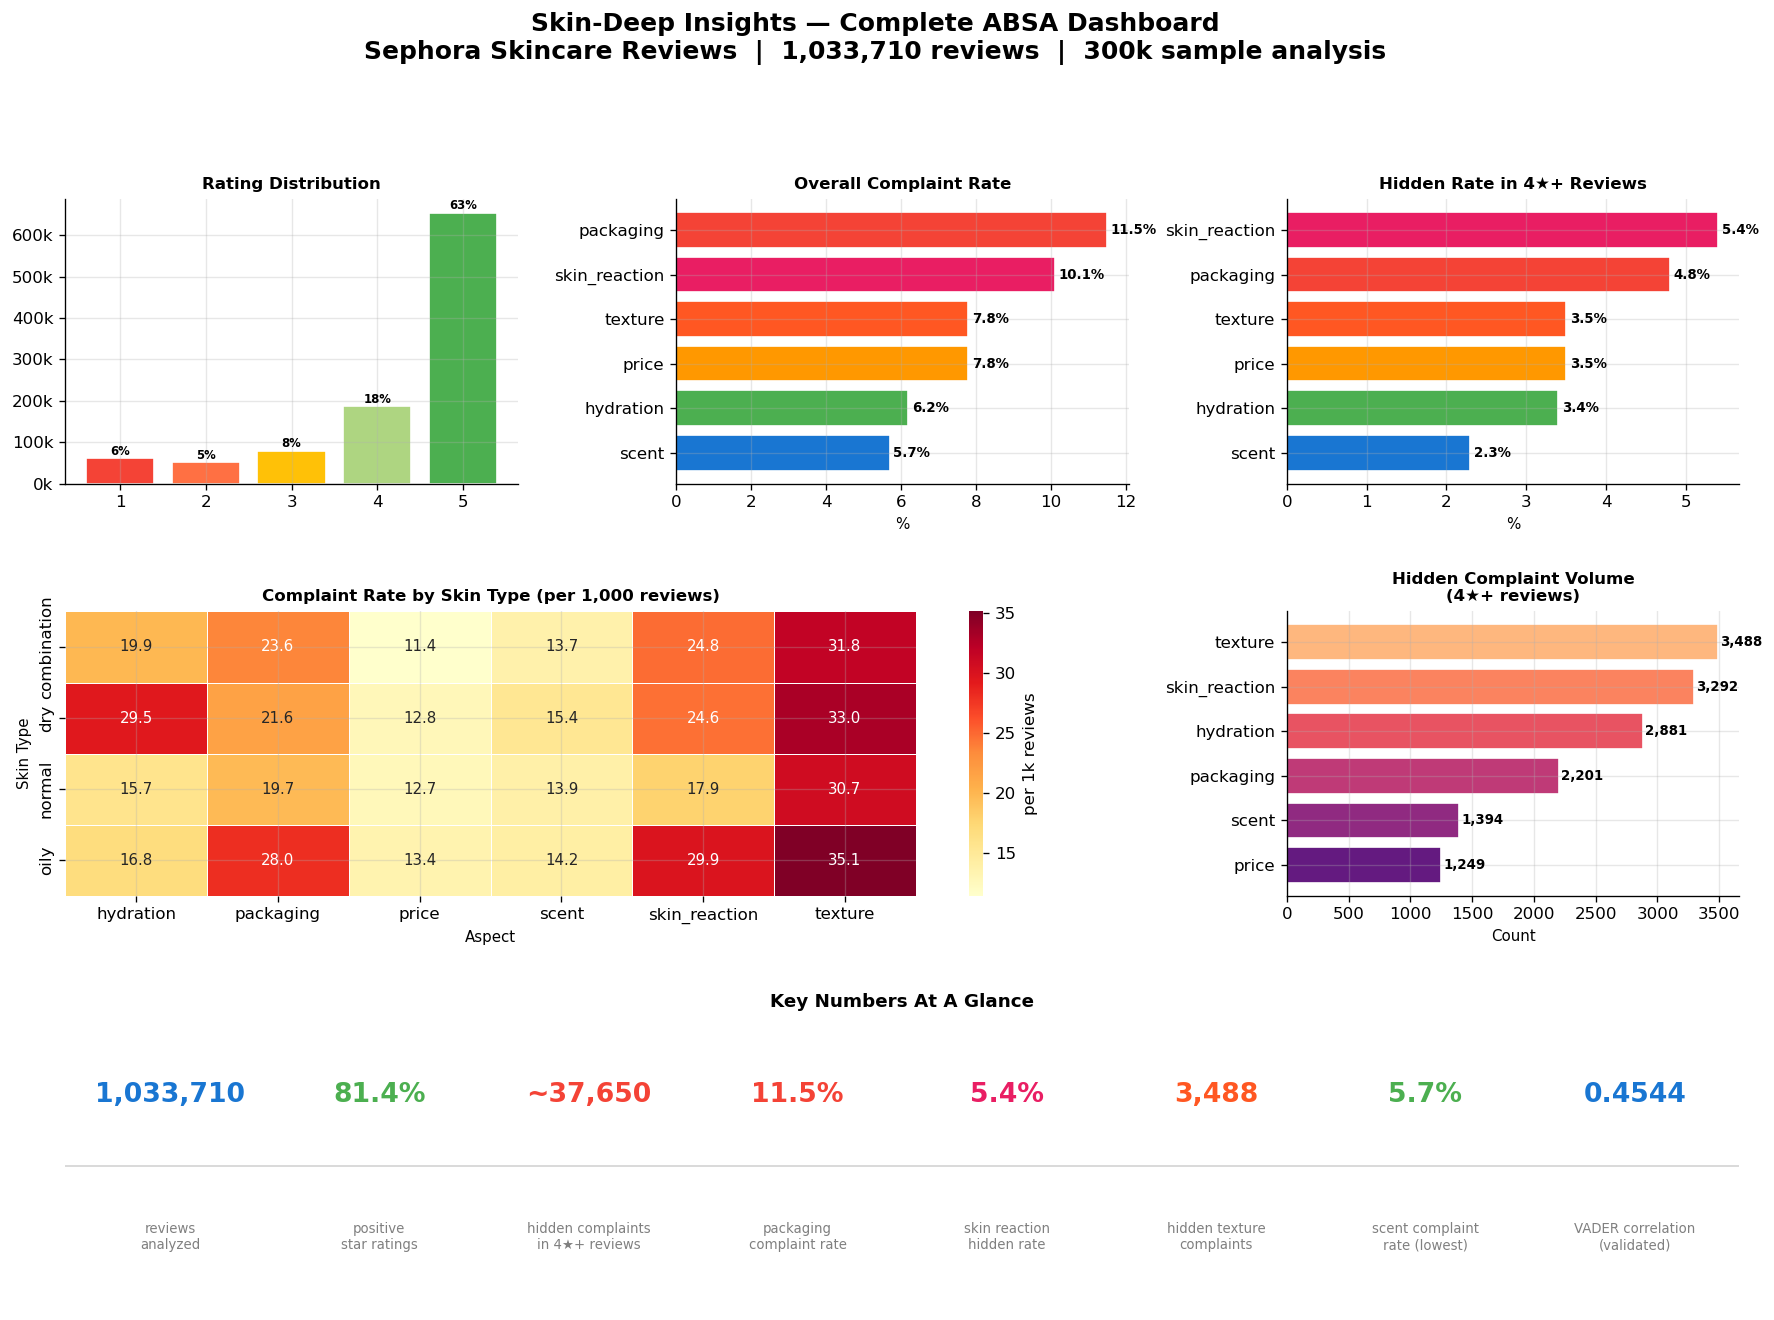

Chart 12 saved.


In [14]:
# ── Chart 12: Complete Dashboard ────────────────────────────────
fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(3, 3, figure=fig,
                         hspace=0.45, wspace=0.35)

# ── Panel 1: Rating distribution ────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
rc  = df['rating'].value_counts().sort_index()
rp  = rc / rc.sum() * 100
ax1.bar(rc.index, rc.values,
        color=[C_NEG,'#FF7043',C_NEU,'#AED581',C_POS],
        edgecolor='white', linewidth=1)
for r, p in zip(rc.index, rp.values):
    ax1.text(r, rc[r]+8000, f'{p:.0f}%',
             ha='center', fontsize=7, fontweight='bold')
ax1.set_title('Rating Distribution', fontweight='bold', fontsize=10)
ax1.set_xticks([1,2,3,4,5])
ax1.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

# ── Panel 2: Aspect complaint rates ─────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ms  = master.sort_values('neg_pct', ascending=True)
bc  = [ASPECT_COLORS.get(a, C_BLUE) for a in ms.index]
bars_p2 = ax2.barh(ms.index, ms['neg_pct'],
                   color=bc, edgecolor='white', linewidth=1)
for bar, val in zip(bars_p2, ms['neg_pct']):
    ax2.text(val+0.1, bar.get_y()+bar.get_height()/2,
             f'{val}%', va='center', fontsize=8, fontweight='bold')
ax2.set_title('Overall Complaint Rate', fontweight='bold', fontsize=10)
ax2.set_xlabel('%', fontsize=9)

# ── Panel 3: Hidden complaint rate ──────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
hs  = master.sort_values('neg_pct_4p', ascending=True)
bc3 = [ASPECT_COLORS.get(a, C_BLUE) for a in hs.index]
bars_p3 = ax3.barh(hs.index, hs['neg_pct_4p'],
                   color=bc3, edgecolor='white', linewidth=1)
for bar, val in zip(bars_p3, hs['neg_pct_4p']):
    ax3.text(val+0.05, bar.get_y()+bar.get_height()/2,
             f'{val}%', va='center', fontsize=8, fontweight='bold')
ax3.set_title('Hidden Rate in 4★+ Reviews', fontweight='bold', fontsize=10)
ax3.set_xlabel('%', fontsize=9)

# ── Panel 4: Skin type heatmap ───────────────────────────────────
ax4 = fig.add_subplot(gs[1, :2])
sns.heatmap(skin_rate, annot=True, fmt='.1f',
            cmap='YlOrRd', ax=ax4,
            cbar_kws={'label': 'per 1k reviews'},
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 9})
ax4.set_title('Complaint Rate by Skin Type (per 1,000 reviews)',
              fontweight='bold', fontsize=10)
ax4.set_xlabel('Aspect', fontsize=9)
ax4.set_ylabel('Skin Type', fontsize=9)

# ── Panel 5: Hidden count ────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
cs  = master.sort_values('neg_count_4p', ascending=True)
cm5 = plt.get_cmap('magma')
cm5_c = cm5(np.linspace(0.3, 0.85, len(cs)))
bars_p5 = ax5.barh(cs.index, cs['neg_count_4p'],
                   color=cm5_c, edgecolor='white', linewidth=1)
for bar, val in zip(bars_p5, cs['neg_count_4p']):
    ax5.text(val+20, bar.get_y()+bar.get_height()/2,
             f'{val:,.0f}', va='center', fontsize=8, fontweight='bold')
ax5.set_title('Hidden Complaint Volume\n(4★+ reviews)',
              fontweight='bold', fontsize=10)
ax5.set_xlabel('Count', fontsize=9)

# ── Panel 6: Key numbers summary ─────────────────────────────────
ax6 = fig.add_subplot(gs[2, :])
ax6.axis('off')

summary_text = [
    ('1,033,710', 'reviews\nanalyzed',       C_BLUE),
    ('81.4%',     'positive\nstar ratings',   C_POS),
    ('~37,650',   'hidden complaints\nin 4★+ reviews', C_NEG),
    ('11.5%',     'packaging\ncomplaint rate', C_NEG),
    ('5.4%',      'skin reaction\nhidden rate', C_PINK),
    ('3,488',     'hidden texture\ncomplaints',  C_ORANGE),
    ('5.7%',      'scent complaint\nrate (lowest)', C_POS),
    ('0.4544',    'VADER correlation\n(validated)',  C_BLUE),
]

for idx, (num, label, color) in enumerate(summary_text):
    x_pos = idx / len(summary_text) + 0.5/len(summary_text)
    ax6.text(x_pos, 0.75, num, ha='center', va='center',
             fontsize=16, fontweight='bold', color=color,
             transform=ax6.transAxes)
    ax6.text(x_pos, 0.25, label, ha='center', va='center',
             fontsize=8, color='gray',
             transform=ax6.transAxes)

ax6.set_title('Key Numbers At A Glance', fontweight='bold',
              fontsize=11, pad=10)
ax6.plot([0, 1], [0.5, 0.5], color='lightgray', linewidth=1, transform=ax6.transAxes)


fig.suptitle(
    'Skin-Deep Insights — Complete ABSA Dashboard\n'
    'Sephora Skincare Reviews  |  1,033,710 reviews  |  300k sample analysis',
    fontsize=15, fontweight='bold', y=1.01
)

plt.savefig('chart12_complete_dashboard.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Chart 12 saved.')

In [16]:
# ── Final: Confirm all charts saved ─────────────────────────────
import os

charts = [
    'chart01_rating_distribution.png',
    'chart02_hidden_dissatisfaction_gap.png',
    'chart03_vader_by_rating.png',
    'chart04_aspect_sentiment.png',
    'chart05_hidden_complaint_rate.png',
    'chart06_rate_vs_volume.png',
    'chart07_skin_type_heatmap.png',
    'chart08_price_tier.png',
    'chart09_tfidf_vocab.png',
    'chart10_trend.png',
    'chart11_priority_matrix.png',
    'chart12_complete_dashboard.png',
]

print('Chart export status:')
print('─' * 50)
for chart in charts:
    exists = os.path.exists(chart)
    status = 'saved' if exists else ' missing'
    size   = f'({os.path.getsize(chart)/1024:.0f} KB)' if exists else ''
    print(f'  {status}  {chart} {size}')
print('─' * 50)
print(f'  Total: {sum(os.path.exists(c) for c in charts)}/{len(charts)} charts saved')

Chart export status:
──────────────────────────────────────────────────
  saved  chart01_rating_distribution.png (63 KB)
  saved  chart02_hidden_dissatisfaction_gap.png (109 KB)
  saved  chart03_vader_by_rating.png (63 KB)
  saved  chart04_aspect_sentiment.png (76 KB)
  saved  chart05_hidden_complaint_rate.png (75 KB)
  saved  chart06_rate_vs_volume.png (110 KB)
  saved  chart07_skin_type_heatmap.png (102 KB)
  saved  chart08_price_tier.png (104 KB)
  saved  chart09_tfidf_vocab.png (111 KB)
  saved  chart10_trend.png (96 KB)
  saved  chart11_priority_matrix.png (107 KB)
  saved  chart12_complete_dashboard.png (256 KB)
──────────────────────────────────────────────────
  Total: 12/12 charts saved


---
## Summary — Visualization Complete

### 12 charts produced across 4 narrative acts:

**ACT 1 — The Problem**
- Chart 01: Rating skew — 81.4% positive, making ratings unreliable
- Chart 02: The gap — ratings say positive, text tells a different story
- Chart 03: VADER validation — sentiment tracks ratings correctly

**ACT 2 — The Findings**
- Chart 04: Aspect sentiment — packaging 11.5%, skin reaction 10.1%
- Chart 05: Hidden rates — skin reaction 5.4%, packaging 4.8% inside 4★+
- Chart 06: Rate vs volume — two different problems, two different solutions
- Chart 07: Skin type heatmap — texture universal, oily skin disproportionate
- Chart 08: Price tier — luxury has highest price complaint rate

**ACT 3 — The Evidence**
- Chart 09: TF-IDF vocabulary — data-driven aspect discovery proof
- Chart 10: Trend 2018–2023 — complaint trajectory over time

**ACT 4 — The Recommendations**
- Chart 11: Priority matrix — rate vs volume, bubble = hidden count
- Chart 12: Complete dashboard — all key numbers in one view

**Proceeding to — Presentation.**